In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

import librosa # 오디오 전처리 - librosa
from tqdm import tqdm # 진행률 확인

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, LSTM, 
    GlobalMaxPooling1D, 
    Dense, Dropout, Masking,
    BatchNormalization,
    MaxPooling1D, Activation
) # Conv1D - 시계열 특성 반영해서 오디오 전처리를 하기 위함.

from sklearn.model_selection import train_test_split # train/validation split
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

from sklearn.utils import class_weight

import matplotlib.pyplot as plt

import random
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ReduceLROnPlateau

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.manifold import TSNE

2025-06-20 03:44:59.846625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750391100.098048      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750391100.175574      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# SEED 고정
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
base_path = '/kaggle/input/2025-1-1-2/kaggle'  

train_audio_dir = '/kaggle/input/2025-1-1-2/kaggle/train'
test_audio_dir = '/kaggle/input/2025-1-1-2/kaggle/test'

# 데이터 불러오기
train_df = pd.read_csv(os.path.join(base_path, 'train.csv'))
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# ID에서 target 문자를 제거하여 실제 .wav 파일 이름과 일치시키기
train_df['file_name'] = train_df['ID'].str.replace('_I_', '_').str.replace('_E_', '_')
test_df['file_name'] = test_df['ID']

# 확장자 제거 
test_df['file_name'] = test_df['ID'].str.replace('.wav', '', regex=False)

# .wav 경로 연결
train_df['file_path'] = train_df['file_name'].apply(lambda x: os.path.join(train_audio_dir, f"{x}.wav"))
test_df['file_path'] = test_df['file_name'].apply(lambda x: os.path.join(test_audio_dir, f"{x}.wav"))

In [4]:
# 확인
print(train_df[['ID', 'file_name', 'file_path']].head())
print(test_df[['ID', 'file_name', 'file_path']].head())

                              ID                    file_name  \
0  steth_20180814_09_37_11_I_004  steth_20180814_09_37_11_004   
1  steth_20180814_09_37_33_I_004  steth_20180814_09_37_33_004   
2  steth_20180814_09_37_59_E_000  steth_20180814_09_37_59_000   
3  steth_20180814_09_37_59_E_008  steth_20180814_09_37_59_008   
4  steth_20180814_09_38_51_E_000  steth_20180814_09_38_51_000   

                                           file_path  
0  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
1  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
2  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
3  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
4  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
                                ID                    file_name  \
0  steth_20190713_09_58_25_007.wav  steth_20190713_09_58_25_007   
1  steth_20180921_15_12_38_011.wav  steth_20180921_15_12_38_011   
2  steth_20190626_15_16_03_004.wav  steth_20190626_15_16_03_004   
3  steth_20

In [5]:
print(train_df.head())
print(test_df.head())

                              ID Target                    file_name  \
0  steth_20180814_09_37_11_I_004      I  steth_20180814_09_37_11_004   
1  steth_20180814_09_37_33_I_004      I  steth_20180814_09_37_33_004   
2  steth_20180814_09_37_59_E_000      E  steth_20180814_09_37_59_000   
3  steth_20180814_09_37_59_E_008      E  steth_20180814_09_37_59_008   
4  steth_20180814_09_38_51_E_000      E  steth_20180814_09_38_51_000   

                                           file_path  
0  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
1  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
2  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
3  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
4  /kaggle/input/2025-1-1-2/kaggle/train/steth_20...  
                                ID                    file_name  \
0  steth_20190713_09_58_25_007.wav  steth_20190713_09_58_25_007   
1  steth_20180921_15_12_38_011.wav  steth_20180921_15_12_38_011   
2  steth_20190626_15_16_03_004.wav  

In [6]:
# 오디오 전처리 - MFCC // librosa

# Target 인코딩
label_map = {'I': 0, 'E': 1}

# 고정 시간 길이 설정 (프레임 수 기준)
fixed_len = 100  

# 빈 리스트 생성
X_train = []
y_train = []

# tqdm
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    file_path = row['file_path']
    
    # 1. 오디오 로드
    signal, sr = librosa.load(file_path, sr=None)
    
    # 2. MFCC 추출 (shape: [n_mfcc, time_steps])
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40) 

    # 3. 패딩
    if mfcc.shape[1] < fixed_len:
        # 오른쪽 패딩
        pad_width = fixed_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')

    # 4. Conv1D 입력에 맞게 전치 (time_steps, features)
    mfcc = mfcc.T  

    # 5. 저장
    X_train.append(mfcc)
    y_train.append(label_map[row['Target']])

# numpy 배열로 변환 (Conv1D 입력: [samples, time_steps, features])
X_train = np.array(X_train)  
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)  
print("y_train shape:", y_train.shape)  

100%|██████████| 4000/4000 [01:31<00:00, 43.66it/s]


X_train shape: (4000, 100, 40)
y_train shape: (4000,)


classification - train

In [21]:
# Conv1D + EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 구성
model = Sequential([
    # Input(shape=(100, 40)), 
    # Conv1D(64, kernel_size=5, activation='relu'),
    # Conv1D(64, kernel_size=5, activation='relu'),
    # Dropout(0.4),
    # Dense(128, activation='relu'),
    # GlobalMaxPooling1D(),
    # Dense(64, activation='relu'),
    # Dense(1, activation='sigmoid')

    Input(shape=(100,40)),
    # Conv1D 블록 1
    Conv1D(64, kernel_size=3, padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Conv1D 블록 2
    Conv1D(128, kernel_size=3, padding='same'), # kernel_size 확장 3 -> 5
    BatchNormalization(),
    Activation('relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # LSTM으로 시간 의존성 학습
    #LSTM(128, return_sequences=False),
    Bidirectional(LSTM(128, return_sequences=False)), # Bidirectional
    Dropout(0.4),

    # 분류기
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
    
])

# 옵티마이저 설정
optimizer = Adam(learning_rate=0.001)  # 기본은 0.001 / 0.0005

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 클래스 가중치 설정 (np.array → dict)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))

model.build(input_shape=(None, 100, 40))

In [22]:
# 학습률 자동 조정
lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-5
)

In [23]:
# train/validation split

# split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,  
    random_state=42,
    stratify=y_train  
)
# 학습
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32, # batch_size = 32 / 64
    callbacks=[early_stop, lr_schedule],
    #callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.5501 - loss: 0.6915 - val_accuracy: 0.6450 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.6456 - loss: 0.6416 - val_accuracy: 0.6575 - val_loss: 0.6082 - learning_rate: 0.0010
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.6807 - loss: 0.6117 - val_accuracy: 0.6662 - val_loss: 0.6084 - learning_rate: 0.0010
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6871 - loss: 0.5968 - val_accuracy: 0.6825 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6896 - loss: 0.5783 - val_accuracy: 0.7250 - val_loss: 0.5478 - learning_rate: 0.0010
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7164 - loss: 0.5607 - val_accuracy: 0.6662 - val_loss: 0.5997 - learning_rate: 0.0010
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.7313 - loss: 0

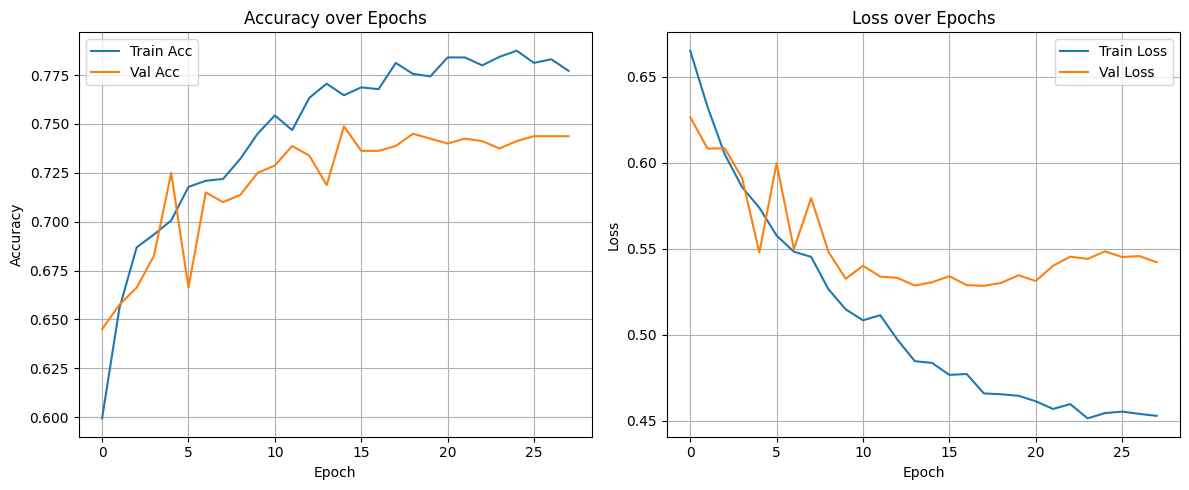

In [24]:
# 그래프 크기 설정
plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

# 전체 출력
plt.tight_layout()
plt.show()

In [25]:
# 전체 accuracy 정리
train_loss, train_acc = model.evaluate(X_tr, y_tr, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Train Accuracy:      0.7928
Validation Accuracy: 0.7387


classification - test

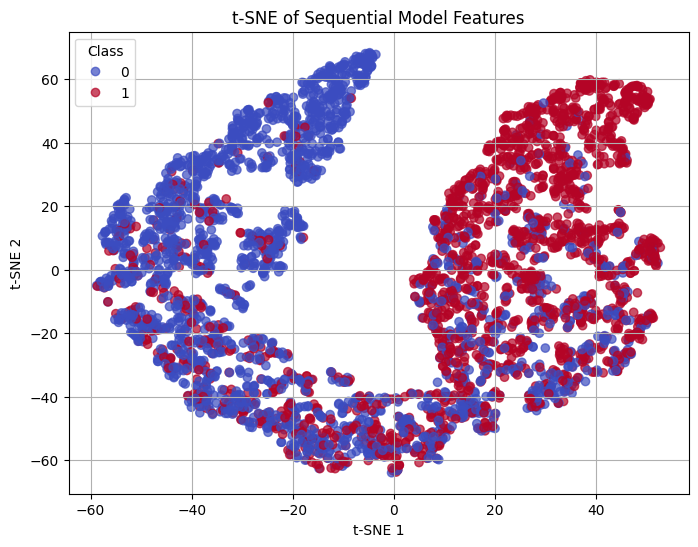

In [28]:

# 0) (필요시) 모델을 build 해주거나 더미 입력으로 한 번 호출해서 내부 그래프 완성
_ = model(tf.zeros((1,100,40)))  # Eager mode 에서는 이 한 줄이면 build 완료

# 1) 앞부분 레이어만 모은 리스트 생성
#    마지막 Dense(1)와 직전 Dropout은 제외하고, 그 전까지의 레이어들만 가져옵니다.
feature_layers = model.layers[:-2]

# 2) X_train을 Tensor로 변환
x = tf.convert_to_tensor(X_train, dtype=tf.float32)

# 3) 앞부분 레이어를 순차적으로 적용
for layer in feature_layers:
    x = layer(x)

# 이제 x는 (n_samples, feature_dim) 형태의 텐서
features = x.numpy()  # NumPy 배열로 변환

# 4) t-SNE 변환
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
features_2d = tsne.fit_transform(features)

# 5) 시각화
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    features_2d[:,0], features_2d[:,1],
    c=y_train, cmap='coolwarm', alpha=0.7
)
plt.legend(*scatter.legend_elements(), title="Class")
plt.title("t-SNE of Sequential Model Features")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.grid(True)
plt.show()

In [16]:
X_test = []
fixed_len = 100  # train과 동일
n_mfcc = 40

for path in tqdm(test_df['file_path']):
    signal, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    if mfcc.shape[1] < fixed_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, fixed_len - mfcc.shape[1])), mode='constant')

    mfcc = mfcc.T  # (time_steps, features)
    X_test.append(mfcc)

X_test = np.array(X_test)  

100%|██████████| 1000/1000 [00:20<00:00, 49.55it/s]


In [17]:
pred_probs = model.predict(X_test)
pred_labels = (pred_probs > 0.5).astype(int).reshape(-1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


In [ ]:
reverse_label_map = {0: 'I', 1: 'E'}
pred_classes = [reverse_label_map[p] for p in pred_labels]

In [ ]:
# 예측 라벨 분포 시각화
unique, counts = np.unique(pred_classes, return_counts=True)
label_distribution = dict(zip(unique, counts))

print("예측된 클래스 분포:", label_distribution)

plt.bar(label_distribution.keys(), label_distribution.values(), color='skyblue')
plt.title("Predicted Class Distribution")
plt.xlabel("Class (I / E)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [ ]:
submission = pd.DataFrame({
    'ID': test_df['ID'],
    'Target': pred_classes
})

submission.to_csv('submission.csv', index=False)